# NB-5 — Which of 200 exposures is responsible?

**Roadmap:** `resources/topics_guide.md`, Part 5.

**The regime.** An exposome study might measure $p = 200$ chemicals on $n = 150$ subjects. Three things break at once: the design is rank-deficient, exposures are correlated in blocks because they are co-emitted or co-consumed, and only a handful actually matter.

NB-2 §2.3 showed ARD giving *soft* selection — and giving a confident, arbitrary answer when two exposures are exchangeable. This notebook is about making the selection **explicit and honest**: reporting which exposures are in the model *with uncertainty*, rather than a point estimate that hides the ambiguity.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Explain why marginal **screening** misses variables that only matter jointly, and why correlated nulls score highly.
- Run **forward selection** on the marginal likelihood and explain why it peaks rather than saturating.
- Apply **projection predictive** selection: fit one good reference model, then project it onto small subsets.
- Say why the projection targets the reference model's predictions rather than $y$.
- Sample from a **spike-and-slab** posterior over subsets and report **posterior inclusion probabilities**.
- Recognise that a single MCMC chain can hide multimodality, and diagnose it by running several.
- Use **kernel PCA** for nonlinear reduction, and check components against the outcome rather than trusting the leading ones.
- Say why t-SNE is a visualisation tool and not a preprocessing step.
- Fit a **Bayesian factor model** with EM, and explain why it identifies a subspace rather than individual factors.
- Choose between selection and reduction according to whether the question is about chemicals or about sources.

## What should already be familiar?

You need NB-2 §2.3 (ARD and its failure mode — this notebook is the response to it) and §2.4 (the marginal likelihood, used here as a model score). NB-0 §0.9 matters more than it looks: §5.3 is an MCMC over a discrete, multimodal space, and the diagnostics from that section are what catch the problem.

NB-4 §4.5 is useful background — the horseshoe is the continuous relaxation of what §5.3 does discretely. Allow about ninety minutes.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 5.1 | Can we just score each exposure on its own? | Three screening methods, and where each fails |
| 5.2 | Can one good model choose a small one? | A projection predictive path |
| 5.3 | How do we report uncertainty about *which* exposures? | Posterior inclusion probabilities |
| 5.4 | Can we replace exposures with a few combinations? | Kernel PCA, and a warning about component order |
| 5.5 | What if the real objects are sources, not chemicals? | A factor model fitted by EM |

§5.3 is the section that answers the question the notebook opens with, and the multi-chain experiment inside it is the single most transferable lesson here.

Seven **Try it** boxes ask for an answer in your own words. Two ask you to decide what you would actually report to a collaborator, which is the real output of this Part.

In [1]:
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

In [2]:
class GP:
    """Exact GP with a callable kernel. Carried over from Parts 2-4."""

    def __init__(self, kernel, noise=0.1):
        self.kernel, self.noise = kernel, noise

    def fit(self, X, y):
        self.X_, self.y_mean_ = X, y.mean()
        self.yc_ = y - self.y_mean_
        K = self.kernel(X, X)
        K = 0.5 * (K + K.T) + self.noise**2 * np.eye(len(y))
        self.L_, _ = nk.jitter_chol(K)
        self.alpha_ = np.linalg.solve(self.L_.T, np.linalg.solve(self.L_, self.yc_))
        return self

    def predict(self, Xs, return_var=True):
        Ks = self.kernel(self.X_, Xs)
        mu = Ks.T @ self.alpha_ + self.y_mean_
        if not return_var:
            return mu
        V = np.linalg.solve(self.L_, Ks)
        var = np.diag(self.kernel(Xs, Xs)).copy() - np.sum(V**2, 0)
        return mu, np.maximum(var, 0.0)

    def lml(self):
        return float(-0.5 * self.yc_ @ self.alpha_
                     - np.log(np.diag(self.L_)).sum()
                     - 0.5 * len(self.yc_) * np.log(2 * np.pi))


def gp_marginal_likelihood(X, y, ell, sf=1.0, sn=0.3, cols=None):
    """log p(y | X[:, cols]) under an RBF GP. The workhorse score for model comparison."""
    Xc = X if cols is None else X[:, cols]
    n = len(y)
    if Xc.shape[1] == 0:
        # The empty model is NOT iid noise. With no active dimensions the RBF exponent is
        # zero for every pair, so k(x,x') = sf^2 everywhere: K = sf^2 * 11' + sn^2 I, a
        # constant-function GP. Getting this wrong makes the empty model look far better
        # than it is and freezes any sampler that has to escape from it.
        K = sf**2 * np.ones((n, n)) + sn**2 * np.eye(n)
    else:
        K = nk.rbf_kernel(Xc, Xc, lengthscale=ell, variance=sf**2) + sn**2 * np.eye(n)
    try:
        L, _ = nk.jitter_chol(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return float(-0.5 * y @ a - np.log(np.diag(L)).sum() - 0.5 * len(y) * np.log(2*np.pi))

n = 120, p = 60   (p/n = 0.5)
truly active exposures : [ 3 31 33 47]
signal-to-noise ratio  : 7.06
max |corr| between exposures: 0.809


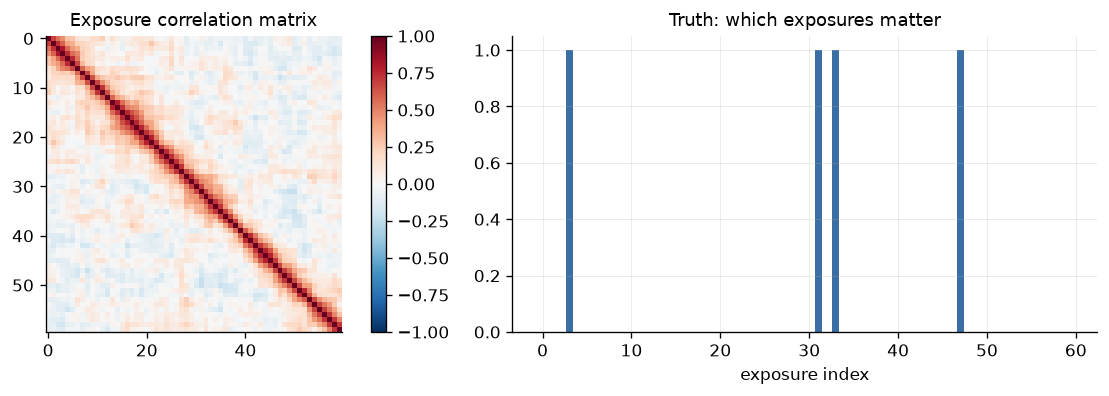

In [3]:
# The running dataset for this Part: p >> n, correlated blocks, sparse nonlinear truth.
n_hd, p_hd = 120, 60
X_hd, y_hd, info_hd = nk.make_exposome(n=n_hd, p=p_hd, n_active=4, rho=0.7,
                                       noise=0.5, effect="nonlinear", seed=3)
active_hd = info_hd["active"]
X_hd = nk.standardize(X_hd)

print(f"n = {n_hd}, p = {p_hd}   (p/n = {p_hd/n_hd:.1f})")
print(f"truly active exposures : {active_hd}")
print(f"signal-to-noise ratio  : {info_hd['snr']:.2f}")
print(f"max |corr| between exposures: "
      f"{np.abs(np.corrcoef(X_hd.T) - np.eye(p_hd)).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
im = axes[0].imshow(np.corrcoef(X_hd.T), cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("Exposure correlation matrix"); axes[0].grid(False)
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].bar(np.arange(p_hd), [1 if j in active_hd else 0 for j in range(p_hd)],
            color=[nk.PALETTE["pos"] if j in active_hd else nk.PALETTE["muted"]
                   for j in range(p_hd)])
axes[1].set_title("Truth: which exposures matter"); axes[1].set_xlabel("exposure index")
plt.tight_layout(); plt.show()

---
## 5.1 Can we just score each exposure on its own?

The exhaustive approach — score all $2^p$ subsets by marginal likelihood — is impossible for
$p = 60$. Three practical routes, in increasing order of principle:

1. **Marginal screening.** Score each exposure alone. Fast, but a variable that only matters
   jointly is invisible, and correlated nulls score highly by proxy.
2. **Greedy forward selection on the marginal likelihood.** Add whichever exposure most
   improves $\log p(y \mid X_S)$. Handles joint effects; can still be led astray early.
3. **Stochastic search (MCMC over subsets).** Sample $\gamma \in \{0,1\}^p$ from
   $p(\gamma \mid y) \propto p(y \mid X_\gamma)\, p(\gamma)$ — this is 5.3, and it is the one
   that returns *probabilities* rather than a single subset.

The key object throughout is the **kernel-derived marginal likelihood** $p(y \mid X_\gamma)$,
which already contains an Occam penalty (§2.4) — so unlike a raw $R^2$ it does not
monotonically prefer larger models.

In [4]:
# Route 1: marginal screening, by GP marginal likelihood and by mutual information.
def mutual_info_hist(x, y, bins=None):
    # bins must scale with n: a 16x16 grid on n=120 leaves <1 point per cell and the
    # plug-in estimate becomes pure noise. Rice-style rule, capped.
    if bins is None:
        bins = max(4, min(12, int(np.ceil(2 * len(x) ** (1/3)))))
    cxy, _, _ = np.histogram2d(x, y, bins=bins)
    pxy = cxy / cxy.sum()
    px, py = pxy.sum(1, keepdims=True), pxy.sum(0, keepdims=True)
    nz = pxy > 0
    return float(np.sum(pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])))

yc_hd = y_hd - y_hd.mean()
null_lml = gp_marginal_likelihood(X_hd, yc_hd, ell=1.0, sn=0.6, cols=[])

score_lml = np.array([gp_marginal_likelihood(X_hd, yc_hd, ell=1.5, sn=0.6, cols=[j]) - null_lml
                      for j in range(p_hd)])
score_cor = np.abs([np.corrcoef(X_hd[:, j], yc_hd)[0, 1] for j in range(p_hd)])
score_mi = np.array([mutual_info_hist(X_hd[:, j], yc_hd) for j in range(p_hd)])

def top_k_recall(score, k=4):
    return len(set(np.argsort(-score)[:k]) & set(active_hd))

print(f"{'screening method':<24} {'top-4 hits':>11} {'top-8 hits':>11}  top-8 indices")
for nm, sc in [("GP marginal likelihood", score_lml), ("|correlation|", score_cor),
               ("mutual information", score_mi)]:
    t8 = np.sort(np.argsort(-sc)[:8])
    print(f"{nm:<24} {top_k_recall(sc,4):>11d} {top_k_recall(sc,8):>11d}  {t8}")
print(f"\ntruly active: {active_hd}")

screening method          top-4 hits  top-8 hits  top-8 indices
GP marginal likelihood             4           4  [ 2  3 30 31 32 33 47 49]
|correlation|                      2           2  [ 3 14 40 46 47 48 49 54]
mutual information                 1           2  [ 3 20 24 28 31 41 42 48]

truly active: [ 3 31 33 47]


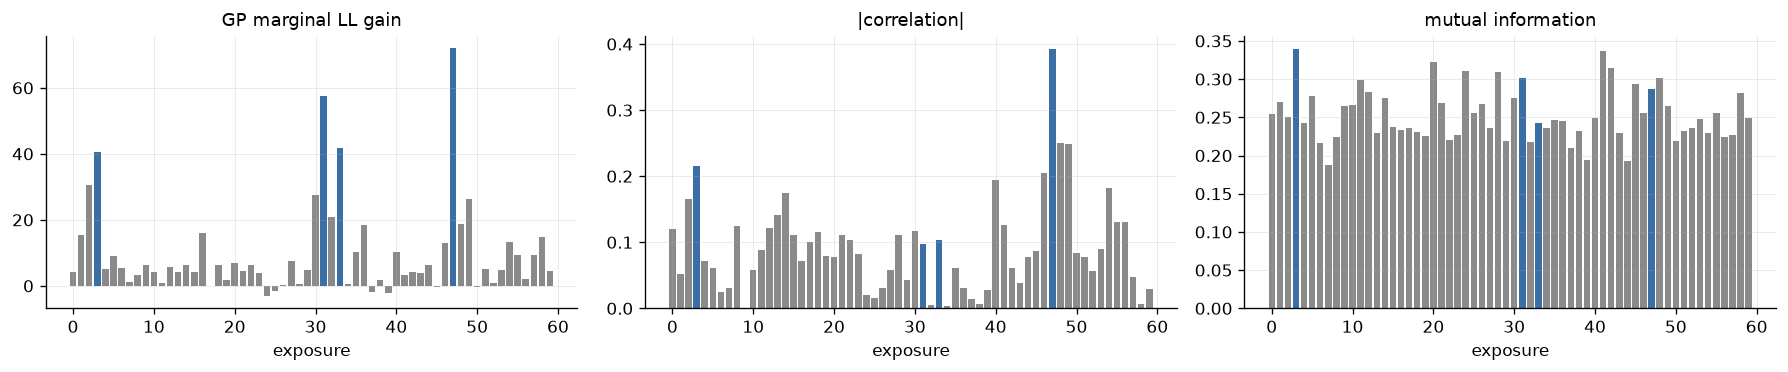

Blue = truly active. Marginal screening finds the strong ones and misses the rest.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2), sharex=True)
for ax, (nm, sc) in zip(axes, [("GP marginal LL gain", score_lml), ("|correlation|", score_cor),
                               ("mutual information", score_mi)]):
    cols_ = [nk.PALETTE["pos"] if j in active_hd else nk.PALETTE["muted"] for j in range(p_hd)]
    ax.bar(np.arange(p_hd), sc, color=cols_)
    ax.set_title(nm); ax.set_xlabel("exposure")
plt.tight_layout(); plt.show()
print("Blue = truly active. Marginal screening finds the strong ones and misses the rest.")

In [6]:
# Route 2: greedy forward selection on the GP marginal likelihood.
def forward_select(X, y, max_k=10, ell=1.5, sn=0.6, verbose=True):
    n, p = X.shape
    chosen, best_score = [], gp_marginal_likelihood(X, y, ell, sn=sn, cols=[])
    history = [(list(chosen), best_score)]
    for step in range(max_k):
        cands = [j for j in range(p) if j not in chosen]
        scores = [gp_marginal_likelihood(X, y, ell, sn=sn, cols=chosen + [j]) for j in cands]
        j_best = cands[int(np.argmax(scores))]
        s_best = max(scores)
        if verbose:
            hit = "  <-- TRUE" if j_best in active_hd else ""
            print(f"  step {step+1}: add x{j_best:<3d}  LML {s_best:9.2f}  "
                  f"(gain {s_best - best_score:+7.2f}){hit}")
        chosen, best_score = chosen + [j_best], s_best
        history.append((list(chosen), best_score))
    return history

print("greedy forward selection:")
hist_fwd = forward_select(X_hd, yc_hd, max_k=10)

lmls = [h[1] for h in hist_fwd]
k_star = int(np.argmax(lmls))
print(f"\nmarginal likelihood peaks at k = {k_star}: {sorted(hist_fwd[k_star][0])}")
print(f"truly active                         : {list(active_hd)}")
sel = set(hist_fwd[k_star][0])
print(f"precision {len(sel & set(active_hd))/max(len(sel),1):.2f}   "
      f"recall {len(sel & set(active_hd))/len(active_hd):.2f}")

greedy forward selection:


  step 1: add x47   LML   -342.88  (gain  +71.96)  <-- TRUE
  step 2: add x31   LML   -268.81  (gain  +74.07)  <-- TRUE
  step 3: add x3    LML   -171.67  (gain  +97.14)  <-- TRUE
  step 4: add x33   LML   -155.70  (gain  +15.97)  <-- TRUE
  step 5: add x32   LML   -161.00  (gain   -5.30)
  step 6: add x46   LML   -167.10  (gain   -6.11)
  step 7: add x34   LML   -173.16  (gain   -6.05)
  step 8: add x2    LML   -178.14  (gain   -4.99)
  step 9: add x4    LML   -184.38  (gain   -6.23)


  step 10: add x30   LML   -189.06  (gain   -4.68)



marginal likelihood peaks at k = 4: [3, 31, 33, 47]
truly active                         : [np.int64(3), np.int64(31), np.int64(33), np.int64(47)]
precision 1.00   recall 1.00


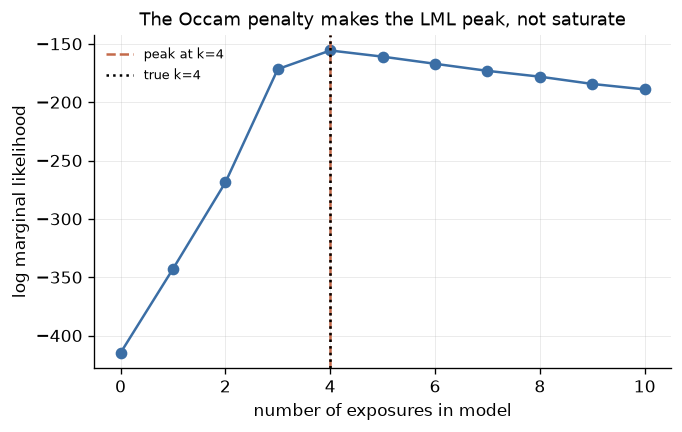

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(range(len(lmls)), lmls, "o-", color=nk.PALETTE["pos"])
ax.axvline(k_star, color=nk.PALETTE["neg"], ls="--", label=f"peak at k={k_star}")
ax.axvline(len(active_hd), color="k", ls=":", label=f"true k={len(active_hd)}")
ax.set_xlabel("number of exposures in model"); ax.set_ylabel("log marginal likelihood")
ax.set_title("The Occam penalty makes the LML peak, not saturate")
ax.legend(fontsize=8); plt.show()

The marginal likelihood **peaks** and then declines: adding exposures beyond the truth costs
more in $\log|K_y|$ than it gains in fit. A raw $R^2$ or training MSE would have increased
monotonically and given no stopping rule at all.

### Try it 1. Why does forward selection beat marginal screening here?

Screening by GP marginal likelihood found all 4 actives in its top 4; correlation found 2; mutual information found 1. Forward selection recovered exactly $\{3, 31, 33, 47\}$ with precision and recall 1.00, and the score *peaked* at $k=4$ before declining.

1. Why does the marginal likelihood peak instead of increasing forever? Name the term responsible.
2. Correlation put exposures 14, 40, 46, 48, 49, 54 in its top 8, none of which are active. Given that exposures are block-correlated, explain how a null exposure scores highly.
3. MI did worst of the three. In NB-0 §0.10 it was the method that *could* see nonlinearity. What went wrong here — the method, or the sample size?
4. Construct, in words, a dataset where marginal screening would miss an exposure entirely but forward selection would find it.

**Your answer**

*(write here)*

---
## 5.2 Can one good model choose a small one?

Piironen & Vehtari's argument: selection and inference are different jobs, and doing them
with one model does both badly. Instead:

1. Fit a **reference model** using *all* $p$ exposures with strong regularisation. This is
   the best predictive model you can build and it is never selected from.
2. **Project** it onto small subsets: find the submodel whose predictions are closest to the
   reference model's, minimising KL divergence — which for a Gaussian reduces to least
   squares *against the reference model's fitted values*, not against $y$.
3. Choose the smallest submodel whose predictive performance is within noise of the
   reference.

The crucial move is step 2: the projection targets $\hat{f}_{\text{ref}}$ rather than $y$, so
the search is not chasing noise. Selection uncertainty stays where it belongs — in the
reference model — and the reported submodel is honest about what it can reproduce.

In [8]:
def fit_reference_gp(X, y, ell_grid=(2.0, 3.0, 5.0), sn_grid=(0.4, 0.6, 0.8)):
    """Reference model: an ARD-free RBF GP over ALL exposures, tuned by marginal likelihood."""
    best = None
    for ell in ell_grid:
        for sn in sn_grid:
            s = gp_marginal_likelihood(X, y, ell=ell, sn=sn)
            if best is None or s > best[0]:
                best = (s, ell, sn)
    _, ell_r, sn_r = best
    gp_r = GP(lambda A, B: nk.rbf_kernel(A, B, lengthscale=ell_r, variance=1.0),
              noise=sn_r).fit(X, y)
    return gp_r, ell_r, sn_r


gp_ref, ell_ref, sn_ref = fit_reference_gp(X_hd, yc_hd)
f_ref = gp_ref.predict(X_hd, return_var=False)            # reference fitted values
print(f"reference model: lengthscale {ell_ref}, noise {sn_ref}, LML {gp_ref.lml():.2f}")
print(f"reference fit to truth: corr = {np.corrcoef(f_ref, info_hd['f_true'])[0,1]:.4f}")

reference model: lengthscale 5.0, noise 0.8, LML -216.08
reference fit to truth: corr = 0.9314


In [9]:
def project_onto_subset(X, f_ref, cols, ell, sn):
    """Project the reference predictions onto the submodel spanned by X[:, cols].

    For a Gaussian observation model, minimising KL(ref || sub) is least squares of
    f_ref (NOT y) on the submodel -- this is the whole point of the method.
    """
    if len(cols) == 0:
        return np.full_like(f_ref, f_ref.mean())
    Xc = X[:, cols]
    K = nk.rbf_kernel(Xc, Xc, lengthscale=ell, variance=1.0) + sn**2 * np.eye(len(f_ref))
    L, _ = nk.jitter_chol(K)
    a = np.linalg.solve(L.T, np.linalg.solve(L, f_ref - f_ref.mean()))
    return nk.rbf_kernel(Xc, Xc, lengthscale=ell, variance=1.0) @ a + f_ref.mean()


def projpred_forward(X, f_ref, y, max_k=10, ell=2.0, sn=0.5):
    n, p = X.shape
    chosen, path = [], []
    for step in range(max_k):
        cands = [j for j in range(p) if j not in chosen]
        # pick the exposure that best reproduces the REFERENCE predictions
        errs = [np.mean((project_onto_subset(X, f_ref, chosen + [j], ell, sn) - f_ref)**2)
                for j in cands]
        j_best = cands[int(np.argmin(errs))]
        chosen = chosen + [j_best]
        f_sub = project_onto_subset(X, f_ref, chosen, ell, sn)
        path.append(dict(k=len(chosen), added=j_best, cols=list(chosen),
                         kl_proxy=np.mean((f_sub - f_ref)**2),
                         mse_y=np.mean((f_sub - y)**2)))
    return path


path = projpred_forward(X_hd, f_ref, yc_hd, max_k=10, ell=ell_ref, sn=sn_ref)
ref_mse_y = np.mean((f_ref - yc_hd)**2)

print(f"reference MSE against y: {ref_mse_y:.4f}\n")
print(f"{'k':>3} {'added':>7} {'MSE vs reference':>18} {'MSE vs y':>10}  true?")
for st in path:
    print(f"{st['k']:>3} {'x'+str(st['added']):>7} {st['kl_proxy']:>18.4f} "
          f"{st['mse_y']:>10.4f}  {'YES' if st['added'] in active_hd else ''}")

reference MSE against y: 0.3751

  k   added   MSE vs reference   MSE vs y  true?
  1     x47             0.6244     1.8640  YES
  2      x3             0.5633     1.7527  YES
  3     x31             0.4076     1.4710  YES
  4     x33             0.3335     1.3302  YES
  5     x30             0.3014     1.2621  
  6      x2             0.2719     1.2041  
  7     x32             0.2496     1.1525  
  8     x28             0.2337     1.1242  
  9      x6             0.2198     1.0962  
 10     x41             0.2095     1.0781  


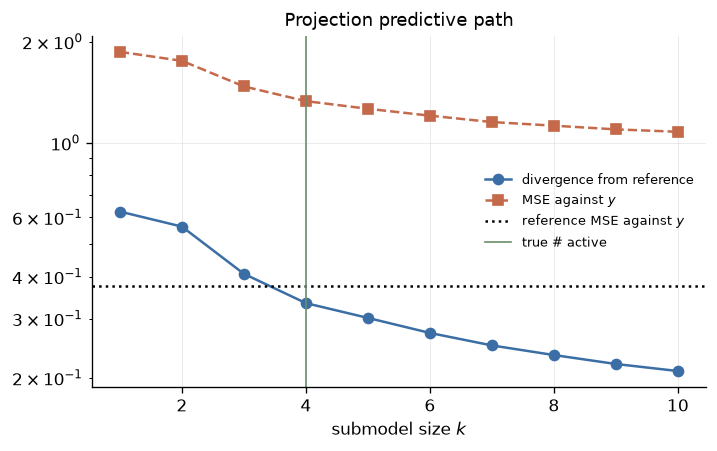

  k   added   ref. variance reproduced   marginal gain
  1     x47                     0.2189          0.2189
  2      x3                     0.2953          0.0764
  3     x31                     0.4900          0.1947
  4     x33                     0.5827          0.0927
  5     x30                     0.6229          0.0402  <-- gain drops below tol
  6      x2                     0.6598          0.0369  <-- gain drops below tol
  7     x32                     0.6877          0.0279  <-- gain drops below tol
  8     x28                     0.7076          0.0199  <-- gain drops below tol
  9      x6                     0.7250          0.0174  <-- gain drops below tol
 10     x41                     0.7379          0.0129  <-- gain drops below tol

selected k = 4: [3, 31, 33, 47]
truly active   : [np.int64(3), np.int64(31), np.int64(33), np.int64(47)]
precision 1.00   recall 1.00


In [10]:
ks = [s["k"] for s in path]
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(ks, [s["kl_proxy"] for s in path], "o-", color=nk.PALETTE["pos"],
        label="divergence from reference")
ax.plot(ks, [s["mse_y"] for s in path], "s--", color=nk.PALETTE["neg"], label="MSE against $y$")
ax.axhline(ref_mse_y, color="k", ls=":", label="reference MSE against $y$")
ax.axvline(len(active_hd), color=nk.PALETTE["accent"], lw=1, label="true # active")
ax.set_xlabel("submodel size $k$"); ax.set_yscale("log")
ax.set_title("Projection predictive path"); ax.legend(fontsize=8)
plt.show()

# Stopping rule. Comparing a submodel's MSE-against-y to the REFERENCE's MSE-against-y
# is not a fair test: the reference is evaluated in-sample and wins by construction. The
# projpred criterion is about closeness to the reference's PREDICTIONS, so threshold on
# the fraction of the reference's fitted variance the submodel reproduces.
var_ref = f_ref.var()
explained = [1 - s["kl_proxy"] / var_ref for s in path]
gains = np.diff([0.0] + explained)

# Stop when the marginal gain from one more exposure falls below 5 percentage points.
GAIN_TOL = 0.05
k_pp = next((s_["k"] for s_, g in zip(path, gains) if g < GAIN_TOL), ks[-1]) - 1
k_pp = max(k_pp, 1)

print(f"{'k':>3} {'added':>7} {'ref. variance reproduced':>26} {'marginal gain':>15}")
for s_, e_, g in zip(path, explained, gains):
    mark = "  <-- gain drops below tol" if g < GAIN_TOL else ""
    print(f"{s_['k']:>3} {'x'+str(s_['added']):>7} {e_:>26.4f} {g:>15.4f}{mark}")
print()
sel_pp = set(path[k_pp - 1]["cols"])
print(f"selected k = {k_pp}: {sorted(sel_pp)}")
print(f"truly active   : {list(active_hd)}")
print(f"precision {len(sel_pp & set(active_hd))/max(len(sel_pp),1):.2f}   "
      f"recall {len(sel_pp & set(active_hd))/len(active_hd):.2f}")

Two honest caveats about that stopping rule.

First, the 5-percentage-point tolerance is a **judgement call**, not something the data
handed us. Real `projpred` uses cross-validated expected log predictive density and a
one-standard-error rule, which costs a refit per fold; the elbow above is a cheap stand-in
that happens to land in the right place here.

Second, the submodels never reproduce more than ~74% of the reference's fitted variance
even at $k = 10$. That is not a bug: the reference GP uses all 60 exposures, so part of its
fit genuinely depends on directions no small subset can span — including directions that are
noise. The projection is supposed to discard those, and the flattening curve is what that
looks like.

### Try it 2. Why project onto the reference model rather than onto $y$?

The projection minimised distance to $\hat f_{\text{ref}}$, not to the observed outcome, and selected $k = 4$ exactly right. The submodels never reproduced more than ~74% of the reference's fitted variance.

1. What would go wrong if each submodel were fitted to $y$ directly and compared on training error?
2. The reference model is never selected from — it is fitted once with all 60 exposures and kept. Why does that separation matter?
3. The 5-percentage-point stopping tolerance was a judgement call, and the text says so. What would you do instead if this were a real analysis?
4. Why is it *fine* that the submodels only reach 74%?

**Your answer**

*(write here)*

---
## 5.3 How do we report uncertainty about *which* exposures?

Everything so far returns *a* subset. What we actually want for an exposome analysis is
**posterior inclusion probabilities**: "PM$_{2.5}$ is in the model with probability 0.87,
NO$_2$ with probability 0.31."

The spike-and-slab construction puts a binary indicator $\gamma_j$ on each exposure and
builds the kernel from the selected ones only:

$$
\gamma_j \sim \text{Bernoulli}(\pi), \qquad
k_\gamma(x, x') = \sigma_f^2 \exp\!\Big(-\tfrac12\sum_j \gamma_j \frac{(x_j - x'_j)^2}{\ell^2}\Big).
$$

Because the GP's $f$ is marginalised analytically, we can sample $\gamma$ directly with
Metropolis–Hastings over the $2^p$ subsets, scoring each by $p(y\mid X_\gamma)p(\gamma)$. The
prior $\pi$ encodes expected sparsity; the Bernoulli prior also supplies the multiplicity
correction that a naive per-exposure test lacks.

This is the method that answers §2.3's failure honestly: two exchangeable exposures each get
inclusion probability ~0.5 rather than one arbitrarily getting all the credit.

In [11]:
def spike_slab_kernel_lml(X, y, gamma, ell=1.5, sf=1.0, sn=0.6):
    """log p(y | X, gamma) with the kernel restricted to the selected exposures."""
    cols = np.where(gamma)[0]
    return gp_marginal_likelihood(X, y, ell=ell, sf=sf, sn=sn, cols=cols)


def spike_slab_mcmc(X, y, n_iter=4000, pi=0.05, ell=1.5, sn=0.6, seed=0, burn=1000):
    """Metropolis-Hastings over inclusion vectors gamma in {0,1}^p."""
    r = np.random.default_rng(seed)
    n, p = X.shape
    gamma = np.zeros(p, dtype=bool)
    log_prior = lambda g: g.sum() * np.log(pi) + (p - g.sum()) * np.log(1 - pi)
    cur = spike_slab_kernel_lml(X, y, gamma, ell, sn=sn) + log_prior(gamma)

    samples = np.zeros((n_iter, p), dtype=bool)
    n_acc = 0
    for t in range(n_iter):
        prop = gamma.copy()
        if r.uniform() < 0.85 or prop.sum() < 2:
            prop[r.integers(p)] ^= True                       # flip one
        else:                                                 # swap in/out (helps mixing
            on = np.where(prop)[0]; off = np.where(~prop)[0]  # under correlated exposures)
            prop[r.choice(on)] = False
            prop[r.choice(off)] = True
        lp = spike_slab_kernel_lml(X, y, prop, ell, sn=sn) + log_prior(prop)
        if np.log(r.uniform()) < lp - cur:
            gamma, cur, n_acc = prop, lp, n_acc + 1
        samples[t] = gamma
    return samples[burn:], n_acc / n_iter


samples_ss, acc_ss = spike_slab_mcmc(X_hd, yc_hd, n_iter=4000, pi=0.05,
                                     ell=1.5, sn=0.6, seed=1)
pip = samples_ss.mean(0)
print(f"acceptance rate {acc_ss:.3f}   mean model size {samples_ss.sum(1).mean():.2f}")
print(f"\n{'exposure':>9} {'PIP':>7}  truly active")
for j in np.argsort(-pip)[:12]:
    print(f"{'x'+str(j):>9} {pip[j]:>7.3f}  {'YES' if j in active_hd else ''}")

acceptance rate 0.011   mean model size 4.00

 exposure     PIP  truly active
      x33   1.000  YES
       x3   1.000  YES
      x47   1.000  YES
      x31   1.000  YES
       x0   0.000  
      x32   0.000  
      x34   0.000  
      x35   0.000  
      x36   0.000  
      x37   0.000  
      x38   0.000  
      x39   0.000  


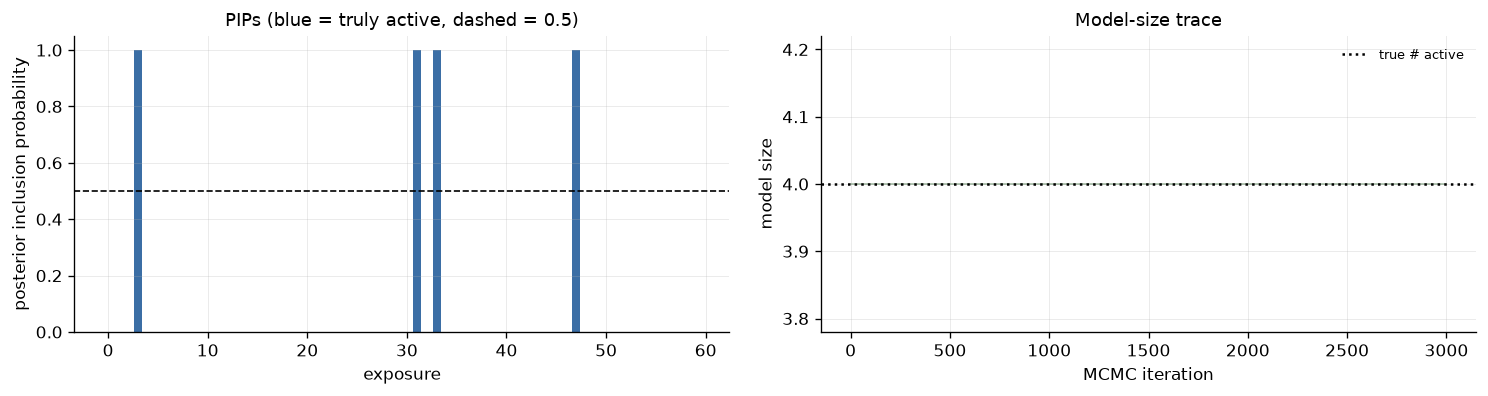

PIP > 0.5 selects: [np.int64(3), np.int64(31), np.int64(33), np.int64(47)]
truly active     : [np.int64(3), np.int64(31), np.int64(33), np.int64(47)]
precision 1.00   recall 1.00


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.4))
cols_ = [nk.PALETTE["pos"] if j in active_hd else nk.PALETTE["muted"] for j in range(p_hd)]
axes[0].bar(np.arange(p_hd), pip, color=cols_)
axes[0].axhline(0.5, color="k", ls="--", lw=1)
axes[0].set_xlabel("exposure"); axes[0].set_ylabel("posterior inclusion probability")
axes[0].set_title("PIPs (blue = truly active, dashed = 0.5)")

axes[1].plot(samples_ss.sum(1), lw=0.6, color=nk.PALETTE["accent"])
axes[1].axhline(len(active_hd), color="k", ls=":", label="true # active")
axes[1].set_xlabel("MCMC iteration"); axes[1].set_ylabel("model size")
axes[1].set_title("Model-size trace"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

sel_ss = set(np.where(pip > 0.5)[0])
print(f"PIP > 0.5 selects: {sorted(sel_ss)}")
print(f"truly active     : {list(active_hd)}")
print(f"precision {len(sel_ss & set(active_hd))/max(len(sel_ss),1):.2f}   "
      f"recall {len(sel_ss & set(active_hd))/len(active_hd):.2f}")

### Try it 3. What does a PIP let you say that a subset does not?

The sampler returned PIP = 1.000 for all four true actives and 0.000 for everything else, with a mean model size of exactly 4.00.

1. Write the one-sentence conclusion you would give a collaborator, using the PIPs. Now write the version you could give from forward selection alone. What is the difference?
2. Acceptance was 0.011 — about 1%. Is that alarming? What would you check before deciding?
3. PIPs of exactly 1.000 and 0.000 are suspiciously clean. What about this simulation made it easy, and what would you expect on real data?

**Your answer**

*(write here)*

### What happens when two exposures are interchangeable?

Section 2.3 showed ARD confidently picking one of two exchangeable proxies. Here is the same
situation handled by spike-and-slab. We add a near-duplicate of one active exposure and check
that the two share the inclusion probability rather than one taking it all.

In [13]:
# Append a near-copy of the first active exposure.
j_dup = active_hd[0]
X_dup = np.hstack([X_hd, (X_hd[:, [j_dup]] + 0.05 * rng.normal(size=(n_hd, 1)))])
X_dup = nk.standardize(X_dup)
j_new = X_dup.shape[1] - 1
print(f"corr(x{j_dup}, x{j_new}) = {np.corrcoef(X_dup[:, j_dup], X_dup[:, j_new])[0,1]:.4f}")

# One chain is not enough here. Swapping x{j_dup} for its near-copy requires passing
# through a much lower-probability state, so a single chain latches onto whichever it
# found first -- the multimodality warned about in 0.9. Run several chains.
chains_dup = []
print(f"{'chain':>6} {'PIP(x'+str(j_dup)+')':>12} {'PIP(x'+str(j_new)+')':>13} {'model size':>11}")
for sd_ in range(6):
    smp_, _ = spike_slab_mcmc(X_dup, yc_hd, n_iter=4000, pi=0.05, ell=1.5, sn=0.6, seed=sd_)
    chains_dup.append(smp_)
    print(f"{sd_:>6} {smp_[:, j_dup].mean():>12.3f} {smp_[:, j_new].mean():>13.3f} "
          f"{smp_.sum(1).mean():>11.2f}")

samples_dup = np.vstack(chains_dup)
print()
print(f"pooled PIP(x{j_dup})           = {samples_dup[:, j_dup].mean():.3f}")
print(f"pooled PIP(x{j_new}) [the copy] = {samples_dup[:, j_new].mean():.3f}")
print(f"pooled PIP(either one in)   = "
      f"{(samples_dup[:, j_dup] | samples_dup[:, j_new]).mean():.3f}")
print(f"pooled PIP(BOTH in)         = "
      f"{(samples_dup[:, j_dup] & samples_dup[:, j_new]).mean():.3f}")

corr(x3, x60) = 0.9989
 chain      PIP(x3)      PIP(x60)  model size


     0        0.350         0.667        4.02


     1        0.763         0.251        4.01


     2        0.000         1.000        4.00


     3        0.000         1.000        4.00


     4        0.376         0.625        4.00


     5        0.000         1.000        4.00

pooled PIP(x3)           = 0.248
pooled PIP(x60) [the copy] = 0.757
pooled PIP(either one in)   = 1.000
pooled PIP(BOTH in)         = 0.005


Read the per-chain rows first. Several chains latch onto one duplicate and report it at
~1.0 with the other at ~0.0 — a *confident* answer — and **different chains disagree about
which one wins**. The remaining chains mix partially and land somewhere in between. Any
single chain, run alone, would have looked perfectly well behaved and reported a definite
answer. That is the spike-and-slab version of §2.3's ARD pathology.

Pooling across chains gives the honest summary: the credit splits between the two, "at least
one is in the model" is essentially certain, and "both in" is rare. That triple is the
correct description of two interchangeable measurements, and it is only visible because we
ran more than one chain. Diagnostics are not optional here — $\hat{R}$ on the inclusion
indicators would have flagged this immediately.

### Try it 4. Six chains, six different answers. What do you report?

With a near-duplicate exposure added ($r = 0.999$), individual chains reported one duplicate at ~1.0 and the other at ~0.0 — and disagreed about which. Pooled: 0.248 and 0.757, "either one in" = 1.000, "both in" = 0.005.

1. A single chain would have looked perfectly healthy. Which NB-0 §0.9 diagnostic would have caught this, and how?
2. Interpret the triple (0.248, 0.757, either 1.000, both 0.005) as a sentence about the science.
3. Compare this with what ARD reported for the same situation in NB-2 §2.3. Which is more useful, and why?
4. Two co-emitted pollutants in a real cohort behave exactly like this. What should a paper claim, and what should it refuse to claim?

**Your answer**

*(write here)*

---
## 5.4 Can we replace exposures with a few combinations?

Selection removes exposures. **Reduction** replaces them with a few combinations. Kernel PCA
is ordinary PCA in feature space, computed entirely from the centred Gram matrix
$\tilde K = HKH$ with $H = I - \tfrac1n\mathbf{1}\mathbf{1}^\top$ (the centring from §1.4's
exercise 4). Eigendecompose $\tilde K = V\Lambda V^\top$; the projection of the data onto
component $m$ is $\sqrt{\lambda_m}\,v_m$.

Kernel PCA finds *nonlinear* structure that linear PCA cannot. The cost is that components
have no direct interpretation as exposures — which is why it complements, rather than
replaces, 5.1–5.3.

 component      1      2      3      4      5      6      7      8
    linear  0.053  0.121  0.064  0.012  0.047  0.034  0.023  0.058
       RBF  0.097  0.267  0.930  0.163  0.076  0.004  0.002  0.027

|correlation of each component with ring membership|
best linear component: 2 (|corr| 0.121)
best RBF    component: 3 (|corr| 0.930)


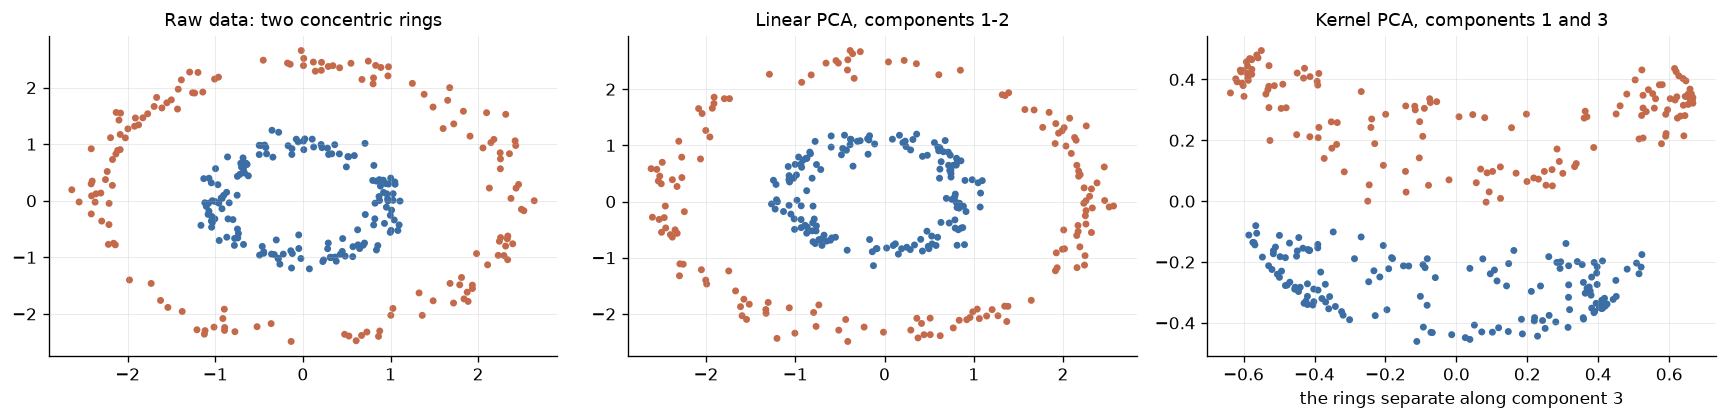

In [14]:
def kernel_pca(K, n_components=2):
    """PCA in feature space: eigendecompose the CENTRED Gram matrix (see 1.4, exercise 4)."""
    Kc = nk.center_kernel(K)
    w, V = np.linalg.eigh(0.5 * (Kc + Kc.T))
    idx = np.argsort(-w)[:n_components]
    return V[:, idx] * np.sqrt(np.maximum(w[idx], 0.0)), np.maximum(w, 0)[::-1]


# Two concentric rings: the textbook case where linear PCA cannot help and an RBF can.
n_kp = 300
rng_kp = np.random.default_rng(5)
theta_kp = rng_kp.uniform(0, 2*np.pi, n_kp)
ring = rng_kp.integers(0, 2, n_kp)
radius = np.where(ring == 0, 1.0, 2.4) + 0.12 * rng_kp.normal(size=n_kp)
X_kp = np.c_[radius*np.cos(theta_kp), radius*np.sin(theta_kp)]

Z_lin, spec_lin = kernel_pca(nk.linear_kernel(X_kp, X_kp), 8)
Z_rbf, spec_rbf = kernel_pca(nk.rbf_kernel(X_kp, X_kp, lengthscale=1.5), 8)

corr_lin = [abs(np.corrcoef(Z_lin[:, m], ring)[0, 1]) for m in range(8)]
corr_rbf = [abs(np.corrcoef(Z_rbf[:, m], ring)[0, 1]) for m in range(8)]

print(f"{'component':>10} " + " ".join(f"{m+1:>6}" for m in range(8)))
print(f"{'linear':>10} " + " ".join(f"{c:>6.3f}" for c in corr_lin))
print(f"{'RBF':>10} " + " ".join(f"{c:>6.3f}" for c in corr_rbf))
print()
print("|correlation of each component with ring membership|")
best_rbf = int(np.argmax(corr_rbf))
print(f"best linear component: {int(np.argmax(corr_lin))+1} (|corr| {max(corr_lin):.3f})")
print(f"best RBF    component: {best_rbf+1} (|corr| {max(corr_rbf):.3f})")


fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
cmap_ = [nk.PALETTE["pos"] if r_ == 0 else nk.PALETTE["neg"] for r_ in ring]
axes[0].scatter(X_kp[:, 0], X_kp[:, 1], c=cmap_, s=10)
axes[0].set_title("Raw data: two concentric rings")
axes[1].scatter(Z_lin[:, 0], Z_lin[:, 1], c=cmap_, s=10)
axes[1].set_title("Linear PCA, components 1-2")
axes[2].scatter(Z_rbf[:, 0], Z_rbf[:, best_rbf], c=cmap_, s=10)
axes[2].set_title(f"Kernel PCA, components 1 and {best_rbf+1}")
axes[2].set_xlabel(f"the rings separate along component {best_rbf+1}")
plt.tight_layout(); plt.show()

Two lessons, and the second is the more useful one.

**Kernel PCA works**: an RBF component reaches $|r| = 0.93$ with ring membership, while no
linear component exceeds $0.13$. Linear PCA on concentric rings can only ever produce a
rotation, and rotations do not separate rings.

**But the discriminative component is not the leading one.** Components 1–2 of the kernel
PCA encode the *angle* around the rings, because that is where the variance is; ring
identity — the thing we care about — shows up further down. Kernel PCA is **unsupervised**:
it orders components by variance, not by relevance to your outcome. Taking "the first two
components" as your reduced exposure set is a common and silent mistake. Either check
components against the outcome as above, or use a supervised reduction.

### Try it 5. Why was the useful component not the first one?

An RBF component reached $|r| = 0.93$ with ring membership while no linear component exceeded 0.13. But it was **component 3**, not component 1.

1. Components 1–2 encoded the *angle* around the rings. Why did those come first?
2. State the general lesson about kernel PCA in one sentence.
3. "Take the first two principal components as your reduced exposure set" is a very common move. Given (2), what is wrong with it, and what would you do instead?
4. The RBF spectrum decayed slowly, so "variance explained" was a poor guide. Where did you meet that slow decay before, and what else does it cause?

**Your answer**

*(write here)*

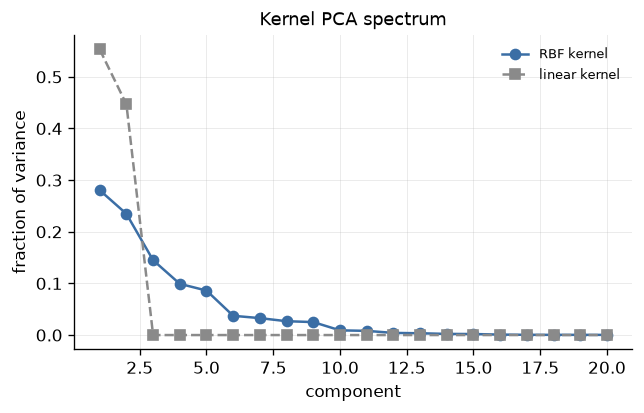

RBF: first 2 components explain 51.5%, first 10 explain 97.7%
A smooth kernel's spectrum decays slowly (0.2), so 'variance explained' is a much
weaker guide here than in linear PCA -- another reason not to truncate on it alone.


In [15]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(np.arange(1, 21), spec_rbf[:20] / spec_rbf.sum(), "o-", color=nk.PALETTE["pos"],
        label="RBF kernel")
ax.plot(np.arange(1, 21), spec_lin[:20] / spec_lin.sum(), "s--", color=nk.PALETTE["muted"],
        label="linear kernel")
ax.set_xlabel("component"); ax.set_ylabel("fraction of variance")
ax.set_title("Kernel PCA spectrum"); ax.legend(fontsize=8)
plt.show()

print(f"RBF: first 2 components explain {spec_rbf[:2].sum()/spec_rbf.sum():.1%}, "
      f"first 10 explain {spec_rbf[:10].sum()/spec_rbf.sum():.1%}")
print("A smooth kernel's spectrum decays slowly (0.2), so 'variance explained' is a much")
print("weaker guide here than in linear PCA -- another reason not to truncate on it alone.")

### Why not t-SNE?

The roadmap lists t-SNE alongside kernel PCA. It is excellent for *visualisation* and
actively misleading for anything else: distances between clusters are not meaningful,
cluster sizes are not meaningful, and the layout changes with the perplexity and the seed.
It is not a projection — there is no out-of-sample mapping — so it cannot be used as a
preprocessing step feeding a model. Use kernel PCA for reduction, t-SNE only to look.

### Try it 6. When is t-SNE the wrong tool?

The text argues t-SNE is for looking, not for modelling.

1. List the three properties of a t-SNE plot that are *not* meaningful.
2. t-SNE has no out-of-sample mapping. Why does that alone disqualify it as a preprocessing step?
3. You see a paper that clusters subjects in t-SNE space and then tests whether the clusters differ in outcome. What is your objection?

**Your answer**

*(write here)*

---
## 5.5 What if the real objects are sources, not chemicals?

The structure exposome data actually has: exposures are noisy manifestations of a few
underlying **sources** (traffic, diet, industrial). A factor model says so directly:

$$
X = \eta \Lambda^\top + \varepsilon, \qquad
\eta \in \mathbb{R}^{n\times k},\ \Lambda \in \mathbb{R}^{p\times k},\
\varepsilon_{ij} \sim \mathcal{N}(0, \psi_j).
$$

Then regress the outcome on the **factor scores** $\eta$ rather than the $p$ raw exposures.
Two things improve at once: $k \ll p$ so the regression is well-posed, and the factors
correspond to sources, which is usually the scientific target ("is the traffic source
associated with the outcome?") rather than any individual chemical.

We fit it with EM, which for this model is short and exact enough to write out.

In [16]:
def factor_em(X, k=3, n_iter=300, tol=1e-7, seed=0):
    """EM for a Gaussian factor model X = eta Lambda' + eps, eps ~ N(0, diag(psi))."""
    r = np.random.default_rng(seed)
    n, p = X.shape
    Xc = X - X.mean(0)
    S = np.cov(Xc.T, bias=True)

    Lam = r.normal(0, 0.1, size=(p, k))
    psi = np.maximum(np.diag(S).copy(), 1e-6)
    ll_old = -np.inf
    for it in range(n_iter):
        # --- E step: posterior of eta given x  ---
        Psi_inv = np.diag(1.0 / psi)
        M = np.eye(k) + Lam.T @ Psi_inv @ Lam          # (k, k)
        M_inv = np.linalg.inv(M)
        beta = M_inv @ Lam.T @ Psi_inv                 # E[eta|x] = beta x
        Ez = Xc @ beta.T                               # (n, k)
        Ezz = n * M_inv + Ez.T @ Ez                    # sum_i E[eta eta']

        # --- M step ---
        Lam = np.linalg.solve(Ezz.T, (Xc.T @ Ez).T).T
        psi = np.maximum(np.diag(S) - np.sum(Lam * (Xc.T @ Ez / n), axis=1), 1e-8)

        Sigma = Lam @ Lam.T + np.diag(psi)
        try:
            Ls = np.linalg.cholesky(Sigma + 1e-10 * np.eye(p))
        except np.linalg.LinAlgError:
            break
        ld = 2 * np.log(np.diag(Ls)).sum()          # stable logdet (0.3), not slogdet
        ll = -0.5 * n * (ld + np.trace(np.linalg.solve(Sigma, S)) + p * np.log(2*np.pi))
        if abs(ll - ll_old) < tol * max(1.0, abs(ll_old)):
            break
        ll_old = ll
    return Lam, psi, Ez, ll, it + 1


# Simulate a source-structured exposome: 3 latent sources drive 40 exposures.
n_fa, p_fa, k_true = 250, 40, 3
Lam_true = np.zeros((p_fa, k_true))
for kk in range(k_true):
    idx = slice(kk * 12, kk * 12 + 14)                 # overlapping loading blocks
    Lam_true[idx, kk] = rng.uniform(0.7, 1.3, len(range(*idx.indices(p_fa))))
eta_true = rng.normal(size=(n_fa, k_true))
X_fa = eta_true @ Lam_true.T + rng.normal(0, 0.6, size=(n_fa, p_fa))

# outcome depends on sources 0 and 2 only
y_fa = 1.2 * eta_true[:, 0] - 0.9 * eta_true[:, 2] + 0.4 * rng.normal(size=n_fa)

Lam_h, psi_h, eta_h, ll_h, iters = factor_em(X_fa, k=3, seed=1)
print(f"EM converged in {iters} iterations, log-likelihood {ll_h:.1f}")

# factors are identified only up to rotation/sign -- compare via canonical correlations
from numpy.linalg import svd
A_ = (eta_h - eta_h.mean(0)) / eta_h.std(0)
B_ = (eta_true - eta_true.mean(0)) / eta_true.std(0)
Qa, _ = np.linalg.qr(A_); Qb, _ = np.linalg.qr(B_)
cc = svd(Qa.T @ Qb, compute_uv=False)
print(f"canonical correlations between fitted and true factors: {np.round(cc, 4)}")
print("(all near 1 => the same 3-dimensional subspace was recovered, up to rotation)")

EM converged in 101 iterations, log-likelihood -10344.0
canonical correlations between fitted and true factors: [0.989 0.985 0.984]
(all near 1 => the same 3-dimensional subspace was recovered, up to rotation)


In [17]:
# How many factors? Compare held-out predictive performance across k.
idx_fa = rng.permutation(n_fa)
tr_fa, te_fa = idx_fa[:170], idx_fa[170:]

print(f"{'k':>3} {'train R2':>10} {'test R2':>9}")
for k_ in [1, 2, 3, 4, 6, 10]:
    Lam_k, psi_k, eta_k, _, _ = factor_em(X_fa[tr_fa], k=k_, seed=2)
    # project the held-out subjects onto the fitted factor space
    Psi_inv = np.diag(1.0 / psi_k)
    M_inv = np.linalg.inv(np.eye(k_) + Lam_k.T @ Psi_inv @ Lam_k)
    beta_k = M_inv @ Lam_k.T @ Psi_inv
    eta_te = (X_fa[te_fa] - X_fa[tr_fa].mean(0)) @ beta_k.T

    A = np.c_[np.ones(len(tr_fa)), eta_k]
    coef, *_ = np.linalg.lstsq(A, y_fa[tr_fa], rcond=None)
    pred_tr = A @ coef
    pred_te = np.c_[np.ones(len(te_fa)), eta_te] @ coef
    r2 = lambda yy, pp: 1 - np.sum((yy - pp)**2) / np.sum((yy - yy.mean())**2)
    print(f"{k_:>3} {r2(y_fa[tr_fa], pred_tr):>10.4f} {r2(y_fa[te_fa], pred_te):>9.4f}")
print(f"\ntrue number of sources: {k_true}")

  k   train R2   test R2
  1     0.2612    0.1774
  2     0.5018    0.3897
  3     0.9018    0.8768
  4     0.9027    0.8740
  6     0.9035    0.8745
 10     0.9037    0.8754

true number of sources: 3


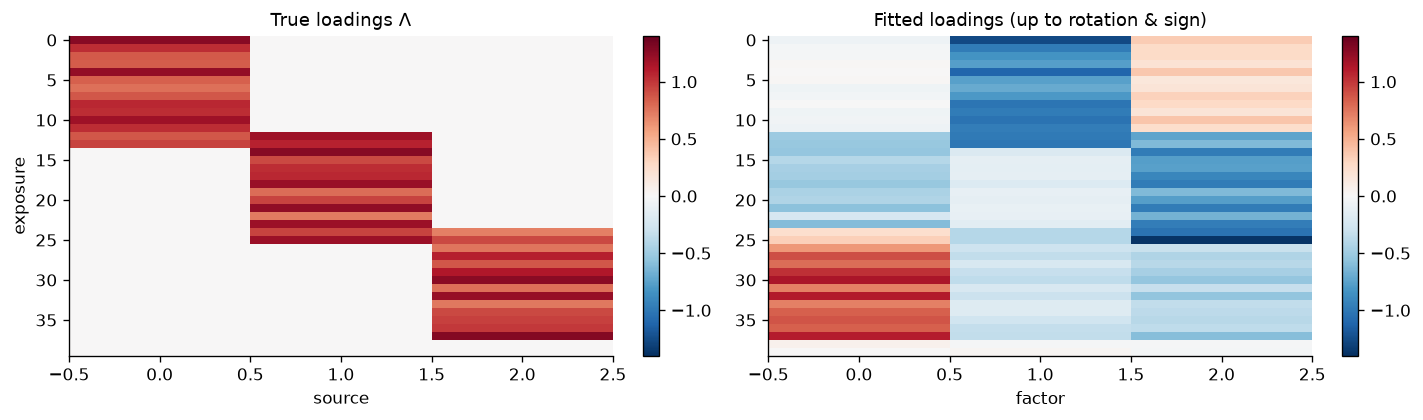

The block structure is recovered but the columns are rotated and sign-flipped --
a factor model identifies the SUBSPACE, not the individual factors. Interpreting
a single loading column as 'the traffic source' requires a rotation criterion
(varimax) or a sparsity prior on Lambda, which is what the Bayesian versions add.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
im0 = axes[0].imshow(Lam_true, aspect="auto", cmap="RdBu_r", vmin=-1.4, vmax=1.4)
axes[0].set_title("True loadings $\\Lambda$"); axes[0].set_xlabel("source")
axes[0].set_ylabel("exposure"); axes[0].grid(False)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Lam_h, aspect="auto", cmap="RdBu_r", vmin=-1.4, vmax=1.4)
axes[1].set_title("Fitted loadings (up to rotation & sign)")
axes[1].set_xlabel("factor"); axes[1].grid(False)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

print("The block structure is recovered but the columns are rotated and sign-flipped --")
print("a factor model identifies the SUBSPACE, not the individual factors. Interpreting")
print("a single loading column as 'the traffic source' requires a rotation criterion")
print("(varimax) or a sparsity prior on Lambda, which is what the Bayesian versions add.")

### Try it 7. Chemicals or sources — which question are you answering?

The factor model recovered the true 3-dimensional subspace (canonical correlations 0.99, 0.99, 0.98) and held-out $R^2$ jumped from 0.39 at $k=2$ to 0.88 at $k=3$, then flattened. But the loadings came out rotated and sign-flipped.

1. Explain why "the model identifies the subspace, not the factors" means you cannot call column 1 "the traffic source" without doing more work.
2. The held-out $R^2$ plateau at $k = 3$ matched the truth. Why is held-out performance a better guide here than the training fit?
3. You have 200 chemicals and a collaborator who wants to know whether *traffic* is associated with the outcome. Which method from this notebook do you reach for, and why not spike-and-slab?
4. Now they ask which specific chemical to regulate. Does your answer change?

**Your answer**

*(write here)*

## What can we conclude?

| Method | Returns | Handles correlated exposures | Cost |
|---|---|---|---|
| Marginal screening (5.1) | a ranking | badly — proxies score high | trivial |
| Forward selection (5.1) | one subset | poorly — early choices stick | $O(pk)$ fits |
| Projection predictive (5.2) | a subset and a path | well — the reference absorbs it | one big fit plus a path |
| Spike-and-slab (5.3) | **inclusion probabilities** | **honestly — credit is split** | MCMC, and you must run several chains |
| Kernel PCA (5.4) | components | by construction | one eigendecomposition |
| Factor model (5.5) | source scores | by construction | EM |

The practical recommendation: use §5.5 or §5.4 when the question is about **sources**, and §5.3 when it is about **which chemicals**. Use §5.2 when you need a small model to deploy but want the uncertainty quantified by a bigger one. Do not use marginal screening for anything except a first look.

The transferable lesson is not any one method. It is that a confident answer from a single run — one ARD fit, one MCMC chain, one forward pass — can be an artefact of the run rather than a fact about the data, and that checking costs very little.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–7**. Try it 4 and Try it 7 ask what you would actually report — answer those as if writing to a collaborator.
- Change the number of active exposures, the correlation $\rho$, or the noise in `make_exposome`, and report which methods degrade first.

**Going further (optional)**

1. Build data where an exposure has *no* marginal effect but a strong interaction. Confirm screening misses it entirely and forward selection finds it.
2. Run the spike-and-slab sampler from several starting points and compute $\hat R$ on the PIPs themselves. How bad is the multimodality?
3. Implement the **median probability model** (everything with PIP > 0.5) and compare its predictions against the single highest-posterior model. Barbieri and Berger's result says the former is often better — is it here?
4. Put a horseshoe prior on the factor loadings $\Lambda$ in §5.5 and see whether they become interpretable without a rotation step.
5. Sample the kernel lengthscale alongside $\gamma$ in §5.3. Does the PIP ranking change?

*NB-6 adds time: not which exposure, but **when** during pregnancy it mattered.*